# Loan Approval Prediction System

## Business Problem

Financial institutions receive thousands of loan applications every day. Manual evaluation of loan applications can be time-consuming, inconsistent, and prone to human bias. The objective of this project is to build a machine learning system that predicts whether a loan application is likely to be approved based on applicant demographics, financial information, credit history, and loan characteristics.

The solution will help automate the loan screening process, improve decision-making speed, reduce operational costs, and support risk assessment.

## Project Goal

Develop and deploy an end-to-end MLOps pipeline that predicts loan approval outcomes and serves predictions through a production-ready REST API deployed on Google Cloud Run.

## Business Impact

* Faster loan processing
* Reduced manual effort
* Consistent approval decisions
* Better risk management
* Scalable prediction service


**Primary Metric:**
F1 Score

**Secondary Metrics:**
Accuracy
Precision
Recall
ROC-AUC

### Success Metric Justification

F1 Score is selected as the primary evaluation metric because loan approval prediction requires balancing both Precision and Recall.

A high Precision ensures that approved loans are more likely to be genuinely eligible, reducing financial risk.

A high Recall ensures that qualified applicants are not unnecessarily rejected.

The F1 Score combines both measures into a single metric and provides a balanced assessment of model performance.

Additional metrics such as Accuracy, Precision, Recall, and ROC-AUC will also be reported for comprehensive evaluation.


## Dataset Overview

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/mlops-LoanPrediction-Poject/data/raw/loan_data.csv")
df.head(5)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [2]:
df.shape

(45000, 14)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [4]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


### Key Observations

* Dataset contains **45,000 records** with no missing values in numerical columns.
* Outliers are present in:

  * **person_age** (maximum age = 144)
  * **person_income** (maximum income = 7,200,766)
  * **person_emp_exp** (maximum experience = 125 years)
* Average loan amount is **9,583**.
* Interest rates range from **5.42% to 20%** with an average of **11.01%**.
* Average loan-to-income ratio is **13.97%**.
* Credit history length ranges from **2 to 30 years**.
* Credit scores range from **390 to 850**, which is within the valid range.
* **loan_status** is moderately imbalanced:

  * **22.22%** positive class (1)
  * **77.78%** negative class (0)
* Outlier treatment is recommended before model training.


### Missing Value Analysis

In [5]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

### Duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

### Target Variable Analysis

In [7]:
df.loan_status.value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

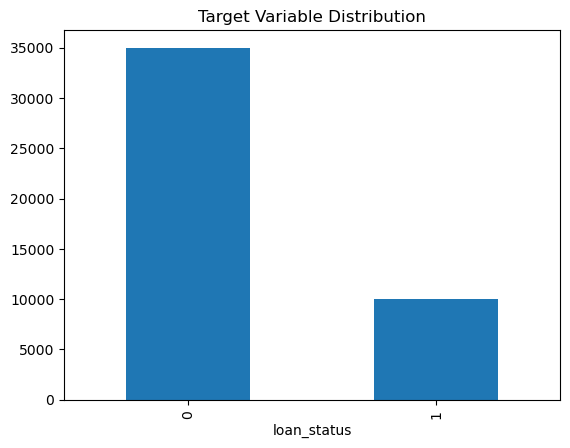

In [8]:
import matplotlib.pyplot as plt

df.loan_status.value_counts().plot(kind='bar')
plt.title("Target Variable Distribution")
plt.show()

### Observation

- The target variable (`loan_status`) is moderately imbalanced.
- Class **0** accounts for approximately **77.8%** of the records.
- Class **1** accounts for approximately **22.2%** of the records.
- Most loan applications belong to Class 0, indicating fewer default cases.
- Class imbalance should be considered during model evaluation and training.

## Numerical Feature Analysis

In [9]:
import seaborn as sns
import math 

n_cols = 3 
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

NameError: name 'num_cols' is not defined

### overview

- **person_age**, **person_income**, and **person_emp_exp** are highly right-skewed and contain significant outliers.
- **loan_amnt** shows a varied distribution with multiple common loan amount ranges.
- **loan_int_rate** is moderately distributed around 10–12%.
- **loan_percent_income** is positively skewed, with most borrowers having a low loan-to-income ratio.
- **cb_person_cred_hist_length** is right-skewed, with most applicants having shorter credit histories.
- **credit_score** follows an approximately normal distribution centered around 630–650.
- **loan_status** is imbalanced, with Class 0 significantly more frequent than Class 1.

### Categorical Feature Analysis

In [ ]:
rows = math.ceil(len(cat_cols) / 2)

fig, axes = plt.subplots(rows, 2, figsize=(15, 4*rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Overview

- The dataset contains a slightly higher number of **male applicants** than female applicants.
- Most applicants have a **Bachelor's degree**, while **Doctorate** holders represent the smallest group.
- **RENT** is the most common home ownership category, followed by **MORTGAGE**; very few applicants fall under **OTHER**.
- Loan purposes are fairly distributed, with **Education** and **Medical** being the most common intents.
- The **previous_loan_defaults_on_file** feature is nearly balanced between **Yes** and **No** categories.
- No major imbalance is observed in most categorical features, except for a few low-frequency categories such as **Doctorate** and **Other** home ownership.

## Correlation Analysis

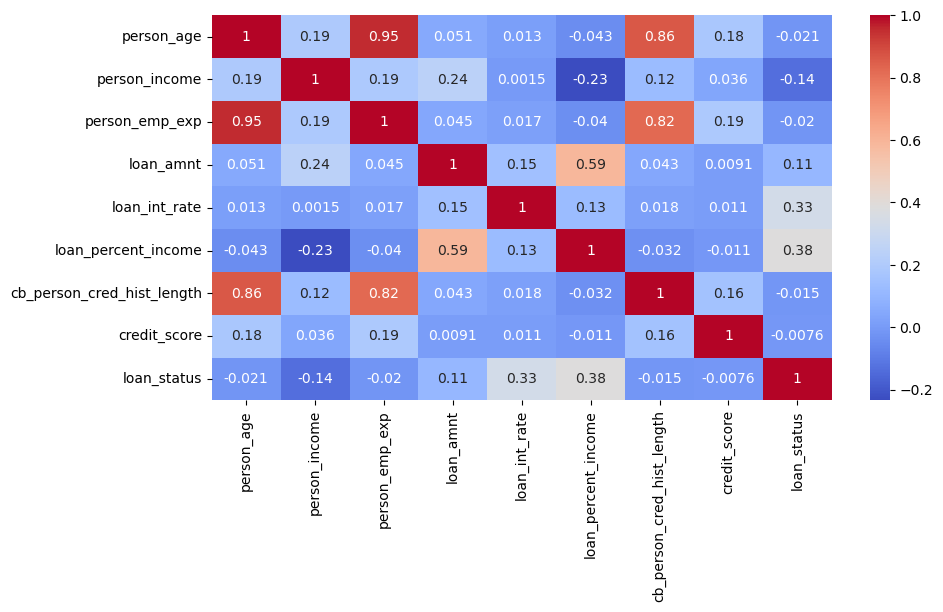

In [23]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,5))

sns.heatmap(corr, cmap="coolwarm",annot=True)

plt.show()

### Overview

- **person_age** and **person_emp_exp** show a very strong positive correlation (**0.95**), indicating potential multicollinearity.
- **person_age** is also highly correlated with **cb_person_cred_hist_length** (**0.86**).
- **loan_amnt** and **loan_percent_income** have a moderate positive correlation (**0.59**), suggesting larger loans contribute to higher income burden.
- **loan_status** has the strongest positive correlation with:
  - **loan_percent_income (0.38)**
  - **loan_int_rate (0.33)**
- **person_income** has a weak negative correlation with **loan_status (-0.14)**, indicating higher-income applicants are slightly less likely to default.
- **credit_score** shows almost no correlation with **loan_status (-0.01)**.
- Most other feature pairs exhibit weak correlations, suggesting limited linear relationships.

### Key Insight
`loan_percent_income` and `loan_int_rate` appear to be the most influential numerical features for predicting `loan_status`, while `person_age`, `person_emp_exp`, and `cb_person_cred_hist_length` may require multicollinearity assessment.

## Feature vs Target Analysis

### Credit Score vs Loan Status

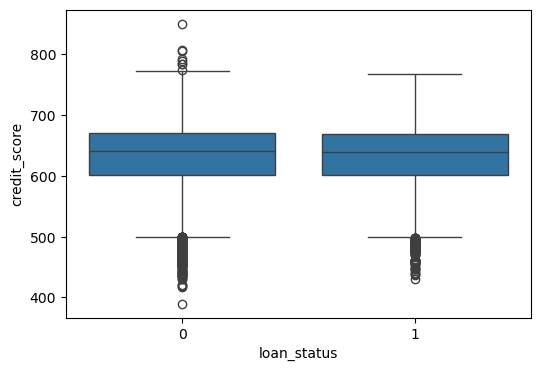

In [33]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="loan_status",
    y="credit_score",
)
plt.show()

### overview

- The median credit score is similar for both loan status groups.
- Most applicants have credit scores between **600 and 670**, regardless of loan status.
- Both groups contain several low-score and high-score outliers.
- The substantial overlap between the distributions suggests that **credit score alone is not a strong predictor of loan status**.
- This observation is consistent with the correlation analysis, which showed a very weak relationship between **credit_score** and **loan_status**.

## Income vs Loan Status

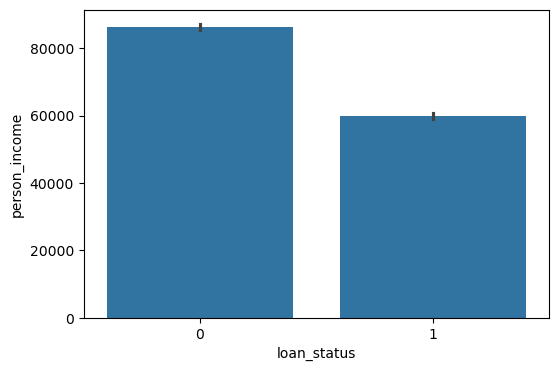

In [34]:
plt.figure(figsize=(6,4))

sns.barplot(data=df,x='loan_status',y='person_income')
plt.show()


### overview

- Applicants with **loan_status = 0** have a noticeably higher average income than those with **loan_status = 1**.
- Borrowers in the default/positive class tend to have lower incomes.
- This suggests that **income may be an important factor in loan repayment ability**.
- The observation aligns with the correlation analysis, which showed a weak negative relationship between **person_income** and **loan_status**.
- Higher income appears to be associated with a lower likelihood of loan default.

## Outlier Detection

In [50]:
num_cols = df.select_dtypes(include="number").columns
outlier_summery = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col]<lower_bound)|
        (df[col]>upper_bound)
        ]

    outlier_count = len(outliers)
    outlier_percentage = round((outlier_count / len(df)) * 100, 2)

    outlier_summery.append([
        col,
        outlier_count,
        outlier_percentage
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Column",
        "Outlier_Count",
        "Outlier_Percentage"
    ]
)     
outlier_df.sort_values(
    by="Outlier_Percentage",
    ascending=False
)

,Column,Outlier_Count,Outlier_Percentage
8,loan_status,10000,22.22
3,loan_amnt,2348,5.22
1,person_income,2218,4.93
0,person_age,2188,4.86
2,person_emp_exp,1724,3.83
6,cb_person_cred_hist_length,1366,3.04
5,loan_percent_income,744,1.65
7,credit_score,467,1.04
4,loan_int_rate,124,0.28


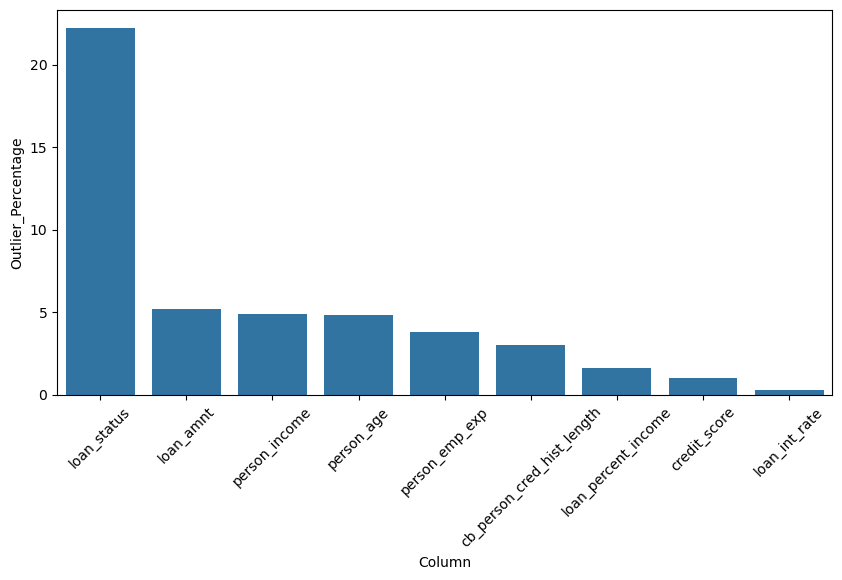

In [53]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=outlier_df.sort_values(
        by="Outlier_Percentage",
        ascending=False
    ),
    x="Column",
    y="Outlier_Percentage"
)

plt.xticks(rotation=45)
plt.show()

### overview

- `loan_status` shows the highest outlier percentage (**22.2%**), which is expected as it is a binary target variable.
- Among predictor variables, **loan_amnt**, **person_income**, and **person_age** have the highest proportion of outliers (around **5%**).
- **person_emp_exp** and **cb_person_cred_hist_length** contain a moderate number of outliers.
- **loan_percent_income**, **credit_score**, and **loan_int_rate** have relatively few outliers.
- The presence of outliers in demographic and financial features suggests the need for further investigation and potential treatment before model training.

### Key Insight
Outliers were detected using the IQR method across numerical features.

The identified outliers appear to represent genuine customer behavior (e.g., high income or large loan amounts) rather than data quality issues. Since tree-based models such as Random Forest and XGBoost are robust to outliers, no outlier removal or capping was performed.

Therefore, all observations were retained for model development.

# EDA Summary

- The dataset contains 45,000 loan application records and 14 features, including numerical and categorical variables.

- No missing values or duplicate records were identified, indicating good data quality.

- The target variable (`loan_status`) shows a moderate class imbalance (~78% vs ~22%), making F1-Score and ROC-AUC important evaluation metrics.

- Numerical features such as income, age, employment experience, and loan amount exhibit positive skewness and contain outliers.

- Outlier analysis using the IQR method revealed that most outliers represent realistic customer behavior rather than data errors; therefore, they will be retained for model training.

- Categorical features such as education, home ownership, loan purpose, and previous loan defaults provide valuable business information and will require encoding.

- Correlation analysis showed a strong relationship between age and employment experience, while most other features exhibited low-to-moderate correlations.

- Income, loan amount, credit profile, and previous default history appear to be key factors influencing loan approval decisions.

## Next Steps

- Feature Engineering
- Categorical Encoding
- Feature Scaling
- Model Training (Logistic Regression, Random Forest, XGBoost)
- MLflow Experiment Tracking
- Model Evaluation and Comparison
- Best Model Selection